In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/online_retail_II.csv.zip', compression='zip')

# Display the first 5 rows of the DataFrame
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
# Display basic information about the DataFrame
display(df.info())

# Display the number of missing values per column
display(df.isnull().sum())

# Display descriptive statistics for numerical columns
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


None

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [3]:
# Drop rows where 'Customer ID' is missing
df_cleaned = df.dropna(subset=['Customer ID'])

# Filter out rows with negative or zero 'Quantity' or 'Price'
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['Price'] > 0)]

# Convert 'InvoiceDate' to datetime objects
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

# Display the shape of the cleaned DataFrame and its info to confirm changes
print(f"Shape of original DataFrame: {df.shape}")
print(f"Shape of cleaned DataFrame: {df_cleaned.shape}")
display(df_cleaned.info())


Shape of original DataFrame: (1067371, 8)
Shape of cleaned DataFrame: (805549, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 55.3+ MB


None

In [4]:
# Calculate TotalPrice
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['Price']

# Get the last transaction date in the dataset and add one day to set the snapshot date
snapshot_date = df_cleaned['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate RFM metrics
rfm_df = df_cleaned.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# Display the first 5 rows of the RFM DataFrame
display(rfm_df.head())

# Display descriptive statistics for RFM values
display(rfm_df.describe())

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


In [5]:
import numpy as np

# Apply log transformation to Recency, Frequency, and Monetary
rfm_log = rfm_df.copy()
rfm_log['Recency'] = np.log(rfm_log['Recency'])
rfm_log['Frequency'] = np.log(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log(rfm_log['Monetary'])

# Display the first 5 rows of the log-transformed RFM DataFrame
display(rfm_log.head())

# Display descriptive statistics for the log-transformed RFM values
display(rfm_log.describe())

,Customer ID,Recency,Frequency,Monetary
0,12346.0,5.786897,2.484907,11.258761
1,12347.0,0.693147,2.079442,8.636454
2,12348.0,4.317488,1.609438,7.610556
3,12349.0,2.944439,1.386294,8.395859
4,12350.0,5.736572,0.000000,5.812338


,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,4.406951,1.202239,6.833841
std,1715.572666,1.636277,1.028614,1.391568
min,12346.000000,0.000000,0.000000,1.081805
25%,13833.250000,3.258097,0.000000,5.854391
50%,15314.500000,4.564348,1.098612,6.801188
75%,16797.750000,5.940171,1.945910,7.743742
max,18287.000000,6.605298,5.986452,13.319281


,Recency_scaled,Frequency_scaled,Monetary_scaled
0,0.843417,1.247093,3.180080
1,-2.269860,0.852873,1.295493
2,-0.054680,0.395905,0.558205
3,-0.893881,0.178951,1.122583
4,0.812658,-1.168894,-0.734129


,Recency_scaled,Frequency_scaled,Monetary_scaled
count,5.878000e+03,5.878000e+03,5.878000e+03
mean,7.494666e-17,-4.835269e-18,1.402228e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-2.693508e+00,-1.168894e+00,-4.133845e+00
25%,-7.021747e-01,-1.168894e+00,-7.039062e-01
50%,9.620016e-02,-1.007523e-01,-2.346665e-02
75%,9.370968e-01,7.230454e-01,6.539230e-01
max,1.343619e+00,4.651521e+00,4.660923e+00


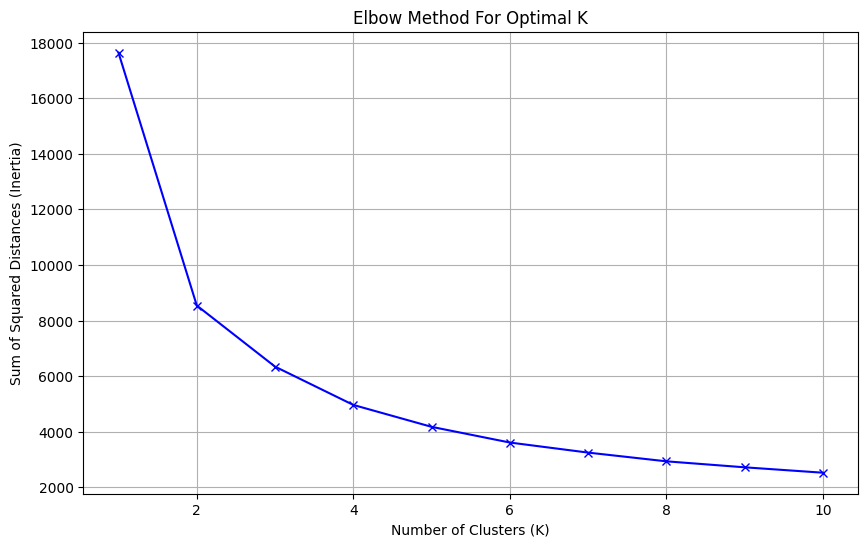

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select the RFM features for scaling
rfm_features = rfm_log[['Recency', 'Frequency', 'Monetary']]

# Scale the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled data back to a DataFrame for easier handling (optional, but good for inspection)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'], index=rfm_log.index)

# Display the first few rows of the scaled data and its descriptive statistics
display(rfm_scaled_df.head())
display(rfm_scaled_df.describe())

# Determine the optimal number of clusters using the Elbow Method
ssd = [] # Sum of squared distances
K = range(1, 11) # Test k from 1 to 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    ssd.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(K, ssd, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()

In [7]:
# Apply K-Means clustering with the chosen number of clusters (e.g., K=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# Add the cluster labels to the original rfm_df
rfm_df['Cluster'] = kmeans.labels_

# Display the first few rows with the new cluster assignments
display(rfm_df.head())

# Analyze the characteristics of each cluster by calculating the mean RFM values
cluster_centers = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).reset_index()

display(cluster_centers.sort_values('Monetary', ascending=False))

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,2
1,12347.0,2,8,5633.32,2
2,12348.0,75,5,2019.40,1
3,12349.0,19,4,4428.69,2
4,12350.0,310,1,334.40,0


,Cluster,Recency,Frequency,Monetary
2,2,27.412080,18.091743,10229.900143
1,1,141.000000,4.382114,1534.067436
0,0,366.348858,1.372145,348.232957


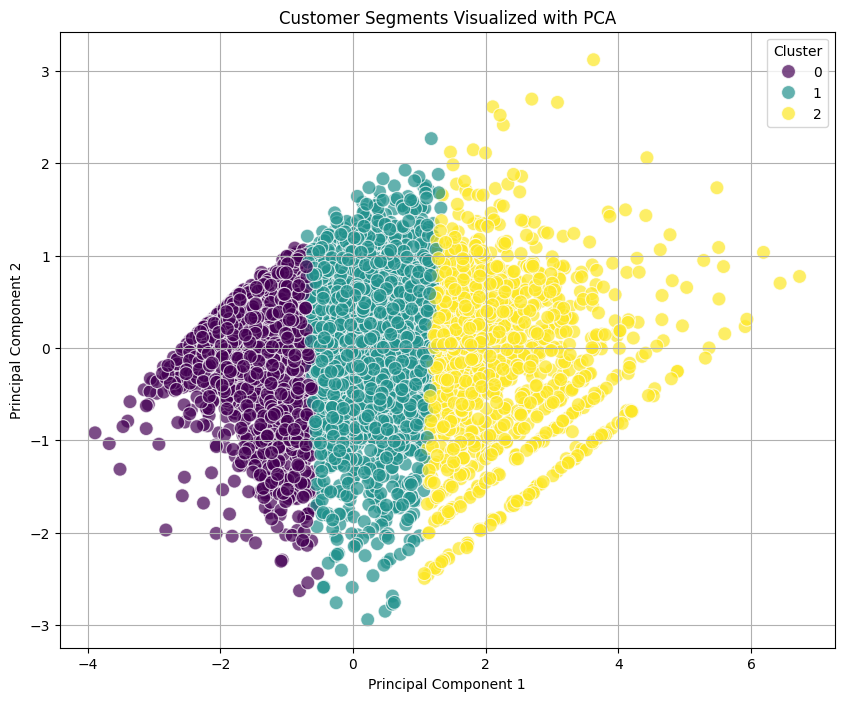

In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA for dimensionality reduction to 2 components
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled) # Use the scaled data for PCA

# Create a DataFrame for PCA results with cluster labels
rfm_pca_df = pd.DataFrame(data=rfm_pca, columns=['PC1', 'PC2'])
rfm_pca_df['Cluster'] = rfm_df['Cluster']

# Plot the clusters using PCA components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=rfm_pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()